In [1]:
import random
import math
from collections import defaultdict, Counter
import matplotlib.pyplot as plt
# ----------------------
# 1. Data Preparation
# ----------------------
with open("hindi_sentences.txt", "r", encoding="utf-8") as f:
    corpus = [line.strip().split() for line in f if line.strip()]

# Add <s>, </s> markers for sentence boundaries
corpus = [["<s>"] + sent + ["</s>"] for sent in corpus]

# Flatten corpus to get vocabulary
vocab = set(word for sent in corpus for word in sent)
V = len(vocab)

In [3]:
print(corpus[1])

['<s>', 'इनेलो', '1987', 'में', 'उस', 'वक्त', 'ऐसे', 'ही', 'दोराहे', 'पर', 'खड़ी', 'थी,', 'जब', 'पूर्व', 'उपप्रधानमंत्री', 'देवीलाल', 'ने', 'अपने', 'पुत्र', 'ओमप्रकाश', 'चौटाला', 'को', 'अपना', 'राजनीतिक', 'उत्तराधिकारी', 'घोषित', 'किया', 'था।', '</s>']


In [ ]:
# ----------------------
# 2. N-gram Counting
# ----------------------
def build_ngram_counts(corpus, n):
    ngram_counts = Counter()
    context_counts = Counter()
    for sent in corpus:
        for i in range(len(sent) - n + 1):
            ngram = tuple(sent[i:i+n])
            context = tuple(sent[i:i+n-1]) if n > 1 else ()
            ngram_counts[ngram] += 1
            context_counts[context] += 1
    return ngram_counts, context_counts

unigram_counts, _ = build_ngram_counts(corpus, 1)
bigram_counts, bigram_contexts = build_ngram_counts(corpus, 2)
trigram_counts, trigram_contexts = build_ngram_counts(corpus, 3)
quad_counts, quad_contexts = build_ngram_counts(corpus, 4)

In [ ]:
# ----------------------
# 3. Probability Functions
# ----------------------

def prob_ngram(ngram, ngram_counts, context_counts, smoothing="none", k=1):
    """Compute probability of an n-gram with different smoothing."""
    n = len(ngram)
    context = tuple(ngram[:-1]) if n > 1 else ()
    count_ngram = ngram_counts[ngram]
    count_context = context_counts[context] if context in context_counts else 0

    if smoothing == "add1":
        return (count_ngram + 1) / (count_context + V)
    elif smoothing == "addk":
        return (count_ngram + k) / (count_context + k * V)
    elif smoothing == "tokentype":
        # Not normalized → just count / (context_count + number of distinct ngrams after context)
        distinct_following = len([ng for ng in ngram_counts if ng[:-1] == context])
        return (count_ngram + 1) / (count_context + distinct_following)
    else:
        # no smoothing
        return count_ngram / count_context if count_context > 0 else 0.0


In [ ]:

# ----------------------
# 4. Sentence Probability
# ----------------------
def sentence_probability(sentence, n, ngram_counts, context_counts, smoothing="none", k=1):
    """Compute probability of a sentence under an n-gram model with smoothing."""
    tokens = ["<s>"] + sentence.split() + ["</s>"]
    log_prob = 0.0
    for i in range(len(tokens) - n + 1):
        ngram = tuple(tokens[i:i+n])
        p = prob_ngram(ngram, ngram_counts, context_counts, smoothing, k)
        if p > 0:
            log_prob += math.log(p)
        else:
            return 0.0  
    return math.exp(log_prob) 


In [ ]:
# ----------------------
# 5. Apply on 1000 Sentences
# ----------------------
random.seed(42)
test_sentences = random.sample(corpus, min(1000, len(corpus)))
test_sentences = [" ".join(sent[1:-1]) for sent in test_sentences]  # remove <s>, </s>


In [ ]:

# Example: compute probability of first test sentence under different models
sample = test_sentences[0]
print("Sample sentence:", sample)

print("Unigram + Add-1:", sentence_probability(sample, 1, unigram_counts, Counter({():sum(unigram_counts.values())}), smoothing="add1"))
print("Bigram + Add-k:", sentence_probability(sample, 2, bigram_counts, bigram_contexts, smoothing="addk", k=0.5))
print("Trigram + TokenType:", sentence_probability(sample, 3, trigram_counts, trigram_contexts, smoothing="tokentype"))

In [29]:

# Example: compute probability of first test sentence under different models
sample = test_sentences[1]
print("Sample sentence:", sample)

print("Unigram + Add-1:", sentence_probability(sample, 1, unigram_counts, Counter({():sum(unigram_counts.values())}), smoothing="add1"))
print("Bigram + Add-k:", sentence_probability(sample, 2, bigram_counts, bigram_contexts, smoothing="addk", k=0.5))
print("Trigram + TokenType:", sentence_probability(sample, 3, trigram_counts, trigram_contexts, smoothing="tokentype"))

Sample sentence: वहीं जिन लोगों के दूसरे सैंपल लिए जा रहे है।ं उनके से अधिकांश 10 दिन बाद भी संक्रमित निकल रहे हैं।
Unigram + Add-1: 2.443980189046119e-69
Bigram + Add-k: 1.023835869517124e-74
Trigram + TokenType: 1.520900984107108e-20


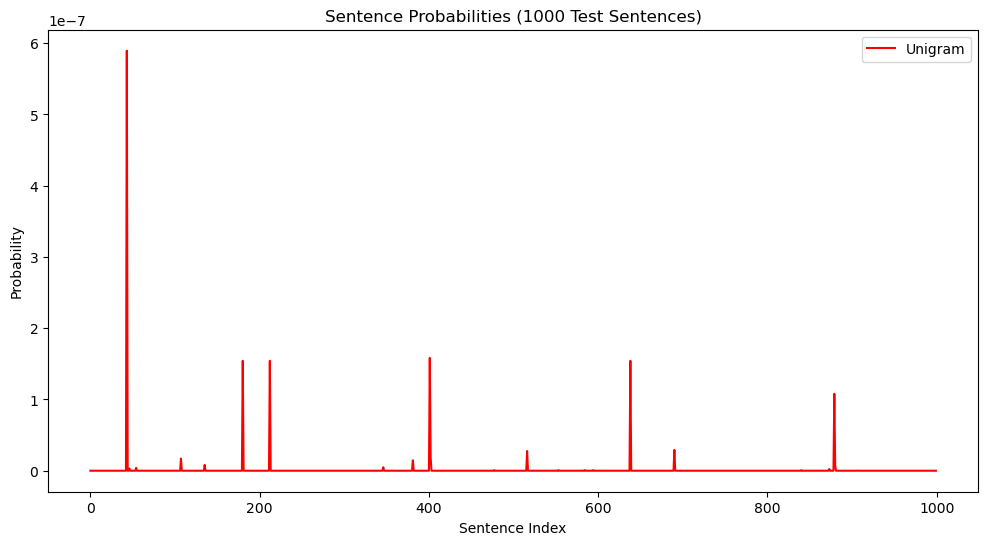

In [46]:
unigram_probs = []
bigram_probs = []
trigram_probs = []
quad_probs = []

for sent in test_sentences:
    unigram_probs.append(sentence_probability(sent, 1, unigram_counts, Counter({(): sum(unigram_counts.values())})))
    bigram_probs.append(sentence_probability(sent, 2, bigram_counts, bigram_contexts))
    trigram_probs.append(sentence_probability(sent, 3, trigram_counts, trigram_contexts))
    quad_probs.append(sentence_probability(sent, 4, quad_counts, quad_contexts))

# ----------------------
# 5. Plot Graph
# ----------------------
plt.figure(figsize=(12,6))
plt.plot(unigram_probs, label="Unigram", color="red")
# plt.plot(bigram_probs, label="Bigram", color="blue")
# plt.plot(trigram_probs, label="Trigram", color="green")
# plt.plot(quad_probs, label="Quadrigram", color="purple")

plt.title("Sentence Probabilities (1000 Test Sentences)")
plt.xlabel("Sentence Index")
plt.ylabel("Probability")
plt.legend()
plt.show()


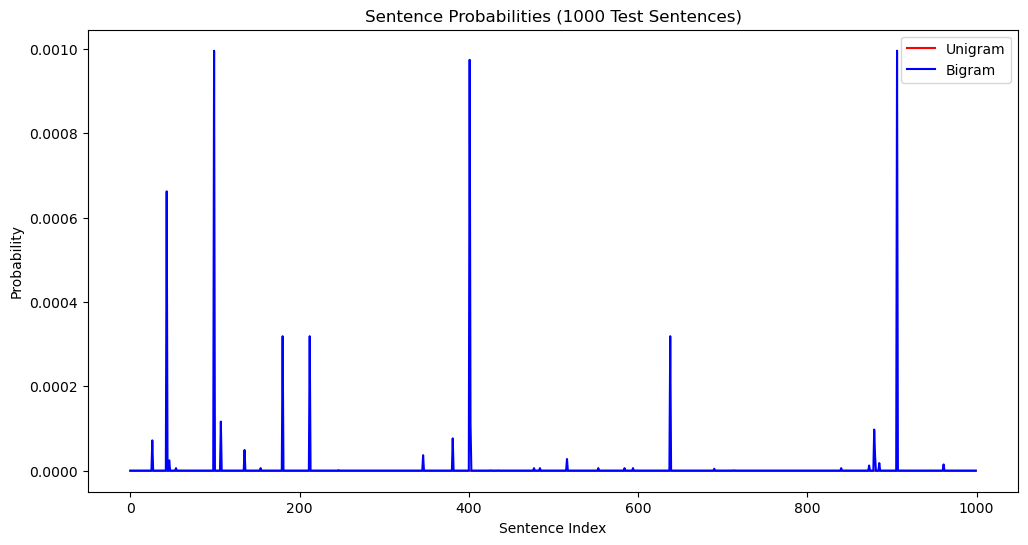

In [47]:
plt.figure(figsize=(12,6))
plt.plot(unigram_probs, label="Unigram", color="red")
plt.plot(bigram_probs, label="Bigram", color="blue")
# plt.plot(trigram_probs, label="Trigram", color="green")
# plt.plot(quad_probs, label="Quadrigram", color="purple")

plt.title("Sentence Probabilities (1000 Test Sentences)")
plt.xlabel("Sentence Index")
plt.ylabel("Probability")
plt.legend()
plt.show()

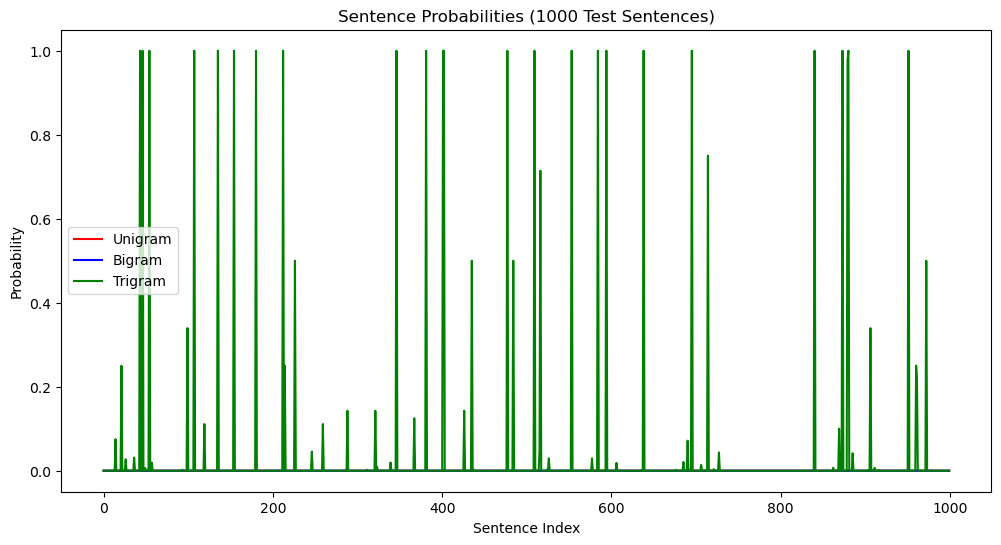

In [48]:
plt.figure(figsize=(12,6))
plt.plot(unigram_probs, label="Unigram", color="red")
plt.plot(bigram_probs, label="Bigram", color="blue")
plt.plot(trigram_probs, label="Trigram", color="green")
# plt.plot(quad_probs, label="Quadrigram", color="purple")

plt.title("Sentence Probabilities (1000 Test Sentences)")
plt.xlabel("Sentence Index")
plt.ylabel("Probability")
plt.legend()
plt.show()

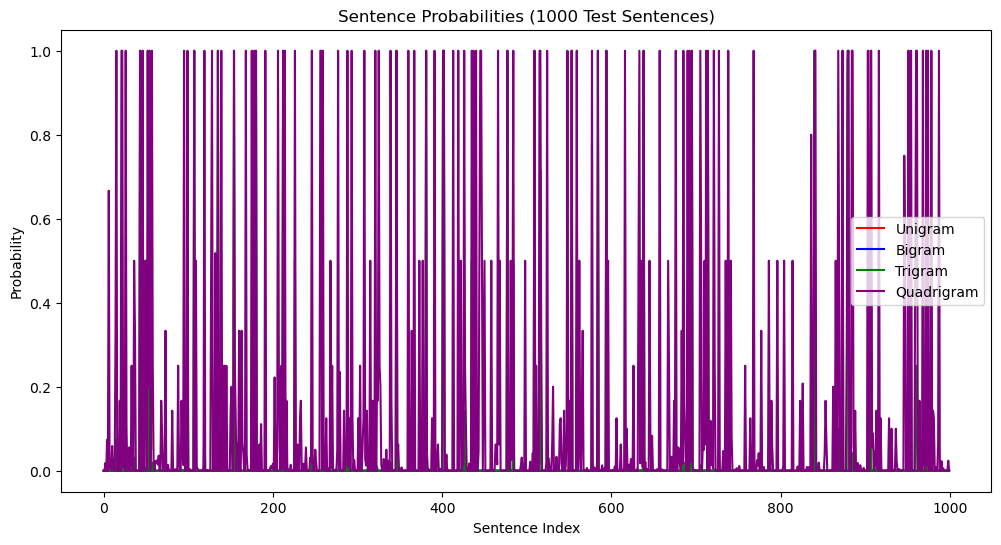

In [49]:
plt.figure(figsize=(12,6))
plt.plot(unigram_probs, label="Unigram", color="red")
plt.plot(bigram_probs, label="Bigram", color="blue")
plt.plot(trigram_probs, label="Trigram", color="green")
plt.plot(quad_probs, label="Quadrigram", color="purple")

plt.title("Sentence Probabilities (1000 Test Sentences)")
plt.xlabel("Sentence Index")
plt.ylabel("Probability")
plt.legend()
plt.show()